In [5]:
import pandas as pd

df = pd.read_csv("../data/flipkart_sales.csv")

df.head()

,Order ID,Product Name,Category,Price (INR),Quantity Sold,Total Sales (INR),Order Date,Payment Method,Customer Rating
0,ORD00001,Educational Book,Books,49069.56,2,98139.12,2024-09-12,Debit Card,3.5
1,ORD00002,Jeans,Clothing,12755.85,4,51023.40,2024-12-18,UPI,3.9
2,ORD00003,Face Cream,Beauty,11092.19,4,44368.76,2024-05-18,Debit Card,4.4
3,ORD00004,Smartwatch,Electronics,32657.81,1,32657.81,2024-11-08,Debit Card,3.2
4,ORD00005,Cookware Set,Home & Kitchen,26590.08,3,79770.24,2024-12-27,UPI,3.1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order ID           1000 non-null   object 
 1   Product Name       1000 non-null   object 
 2   Category           1000 non-null   object 
 3   Price (INR)        1000 non-null   float64
 4   Quantity Sold      1000 non-null   int64  
 5   Total Sales (INR)  1000 non-null   float64
 6   Order Date         1000 non-null   object 
 7   Payment Method     1000 non-null   object 
 8   Customer Rating    1000 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 70.4+ KB


In [7]:
df.describe()


,Price (INR),Quantity Sold,Total Sales (INR),Customer Rating
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,24520.258260,3.097000,75213.112740,3.011100
std,14187.611227,1.410525,59457.598352,1.145408
min,139.850000,1.000000,419.550000,1.000000
25%,12378.905000,2.000000,28581.765000,2.000000
50%,24650.015000,3.000000,57358.300000,3.100000
75%,35981.925000,4.000000,110618.595000,4.000000
max,49911.750000,5.000000,243903.900000,5.000000


In [8]:
df.isnull().sum()

Order ID             0
Product Name         0
Category             0
Price (INR)          0
Quantity Sold        0
Total Sales (INR)    0
Order Date           0
Payment Method       0
Customer Rating      0
dtype: int64

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order ID           1000 non-null   object        
 1   Product Name       1000 non-null   object        
 2   Category           1000 non-null   object        
 3   Price (INR)        1000 non-null   float64       
 4   Quantity Sold      1000 non-null   int64         
 5   Total Sales (INR)  1000 non-null   float64       
 6   Order Date         1000 non-null   datetime64[ns]
 7   Payment Method     1000 non-null   object        
 8   Customer Rating    1000 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 70.4+ KB


In [11]:
df['Month'] = df['Order Date'].dt.month

In [12]:
df.head()

,Order ID,Product Name,Category,Price (INR),Quantity Sold,Total Sales (INR),Order Date,Payment Method,Customer Rating,Month
0,ORD00001,Educational Book,Books,49069.56,2,98139.12,2024-09-12,Debit Card,3.5,9
1,ORD00002,Jeans,Clothing,12755.85,4,51023.40,2024-12-18,UPI,3.9,12
2,ORD00003,Face Cream,Beauty,11092.19,4,44368.76,2024-05-18,Debit Card,4.4,5
3,ORD00004,Smartwatch,Electronics,32657.81,1,32657.81,2024-11-08,Debit Card,3.2,11
4,ORD00005,Cookware Set,Home & Kitchen,26590.08,3,79770.24,2024-12-27,UPI,3.1,12


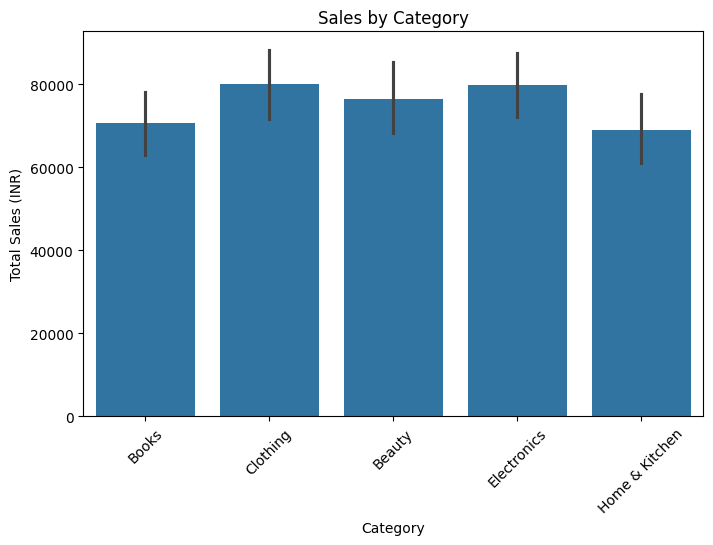

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Total Sales (INR)', data=df)
plt.xticks(rotation=45)
plt.title("Sales by Category")
plt.show()

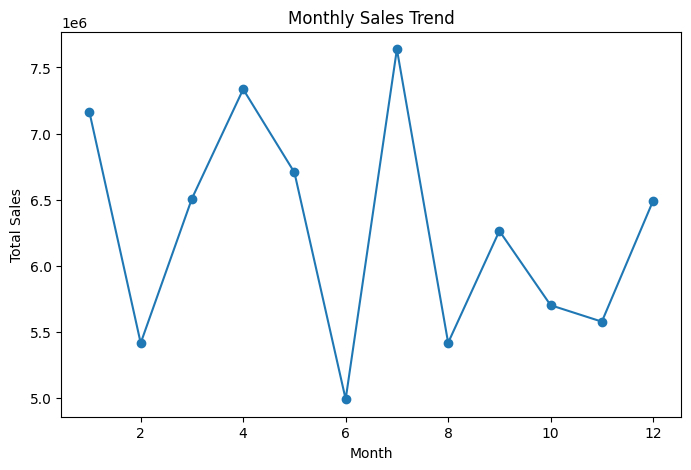

In [14]:
monthly_sales = df.groupby('Month')['Total Sales (INR)'].sum()

monthly_sales.plot(kind='line', marker='o', figsize=(8,5))
plt.title("Monthly Sales Trend")
plt.ylabel("Total Sales")
plt.show()

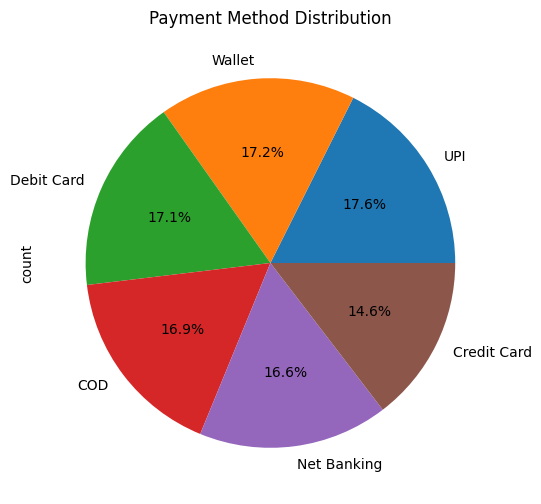

In [18]:
df['Payment Method'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Payment Method Distribution")
plt.show()

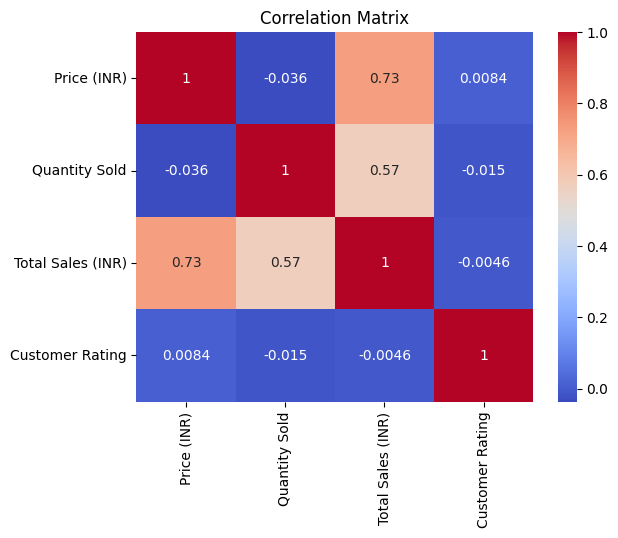

In [19]:
corr = df[['Price (INR)','Quantity Sold','Total Sales (INR)','Customer Rating']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [21]:
X = df[['Price (INR)', 'Quantity Sold', 'Customer Rating', 'Month']]
y = df['Total Sales (INR)']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 14486.649002192486
R2 Score: 0.8955903267732452


In [26]:
import pandas as pd

new_data = pd.DataFrame({
    'Price (INR)': [20000],
    'Quantity Sold': [3],
    'Customer Rating': [4.5],
    'Month': [12]
})

prediction = model.predict(new_data)

print("Predicted Sales:", prediction)

Predicted Sales: [58543.55587054]


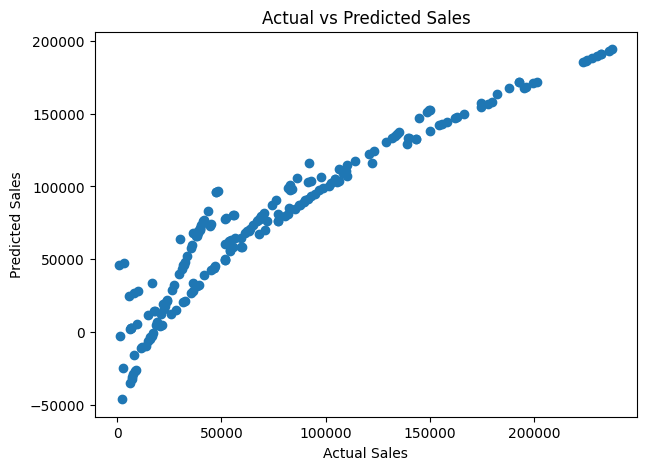

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [28]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_
})

importance

,Feature,Importance
0,Price (INR),3.141819
1,Quantity Sold,24795.062201
2,Customer Rating,140.222133
3,Month,-25.469844


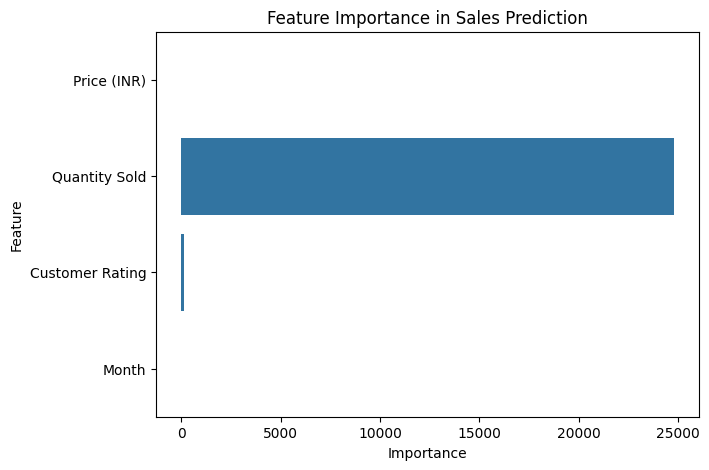

In [29]:
import seaborn as sns

plt.figure(figsize=(7,5))

sns.barplot(x='Importance', y='Feature', data=importance)

plt.title("Feature Importance in Sales Prediction")

plt.show()

In [30]:
results = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': y_pred
})

results.to_csv("../data/sales_predictions.csv", index=False)

In [31]:
from sklearn.ensemble import RandomForestRegressor

In [32]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [33]:
rf_pred = rf_model.predict(X_test)

In [34]:
from sklearn.metrics import mean_absolute_error, r2_score

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest R2:", rf_r2)

Random Forest MAE: 588.4711080000105
Random Forest R2: 0.9997951580006645


In [35]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "R2 Score": [r2, rf_r2]
})

comparison

,Model,MAE,R2 Score
0,Linear Regression,14486.649002,0.895590
1,Random Forest,588.471108,0.999795


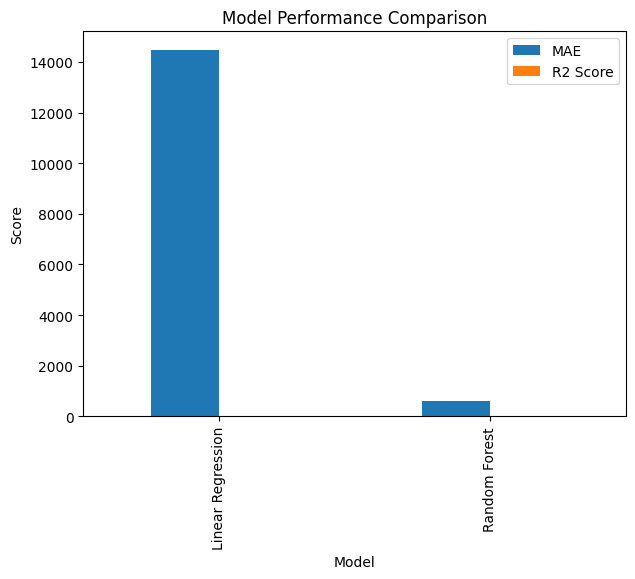

In [38]:
comparison.set_index("Model").plot(kind="bar", figsize=(7,5))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

In [39]:
df.to_csv("../data/clean_flipkart_sales.csv", index=False)

In [40]:
results = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales (Linear)": y_pred,
    "Predicted Sales (Random Forest)": rf_pred
})

results.to_csv("../data/model_predictions.csv", index=False)